# Single‑Cell RNA‑seq Analysis of Parkinson Disease

### Introduction
Parkinson’s disease (PD) is a common neurodegenerative disorder characterized by progressive motor and non‑motor symptoms, with pathological features extending beyond dopaminergic neuron loss to include widespread transcriptional changes across multiple brain cell types. Recent advances in single‑cell and single‑nucleus RNA sequencing have enabled high‑resolution profiling of cellular heterogeneity in human brain tissue, allowing cell type–specific investigation of disease mechanisms that are not detectable in bulk transcriptomic analyses. The dataset used in this project (GEO accession GSE202210) provides single‑nucleus RNA‑sequencing profiles from postmortem prefrontal cortex tissue of individuals with late‑stage PD and age‑matched controls, offering a valuable resource for studying molecular and cellular alterations associated with Parkinson’s disease at single‑cell resolution.

### Project Description
This project performs a comprehensive bioinformatics analysis of the GSE202210 single‑cell RNA‑sequencing dataset to compare transcriptional profiles between Parkinson’s disease and control brain samples. Using a Scanpy‑based workflow, the analysis includes quality control, normalization, dimensionality reduction, clustering, and differential gene expression analyses to identify disease‑associated cell populations and genes. Gene enrichment analysis was further performed to identify biological processes and pathways over‑represented among the significantly differentially expressed genes. In addition, a supervised machine‑learning approach is implemented using a Random Forest classifier trained on differentially expressed genes to evaluate their ability to distinguish PD from control samples. Together, this integrated approach aims to characterize PD‑related transcriptional signatures and assess their potential relevance as biomarkers or disease predictors.

### Source
The single‑cell RNA‑sequencing data analyzed in this project were obtained from the publicly available GEO dataset GSE202210. In the original study, brain nuclei were isolated from postmortem prefrontal cortex tissue of 12 individuals with and without Parkinson’s disease (PD) using sucrose gradient ultracentrifugation. Single‑nucleus RNA‑sequencing libraries were generated using the 10x Chromium platform (10x Genomics), and sequencing was performed on an Illumina NovaSeq 6000 S4 platform. This dataset captures transcriptomic profiles of diverse brain cell types and provides a high‑resolution resource for investigating molecular changes associated with Parkinson’s disease.

Reference  
Zhu, B., Park, J.-M., Coffey, S. R., Russo, A., Hsu, I.-U., Wang, J., Zhang, L., Chandra, S. S., & Hafler, D. A. (2022). Single‑cell transcriptomic and proteomic analysis of Parkinson’s disease brains (GEO Accession No. GSE202210). National Center for Biotechnology Information. https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?acc=GSE202210


### Analysis Pipeline
This notebook performs a complete single‑cell RNA‑sequencing (scRNA‑seq) analysis pipeline
using Scanpy. The analysis includes:

- Loading and merging multiple 10x Genomics samples
- Quality control and filtering
- Normalization and dimensionality reduction
- Clustering and marker gene identification
- Differential expression analysis (PD vs Control)
- Gene Enrichment Analysis 
- Machine‑learning classification using Random Forest

The goal is to identify cell populations, disease‑associated genes,
and predictive biomarkers for Parkinson’s Disease (PD).

### Import Required Libraries

Basic Python and Scanpy libraries are imported to handle
data processing, file management, and single‑cell analysis.

In [ ]:
# Single-cell analysis
import scanpy as sc

# Data manipulation
import pandas as pd

# File and path handling
import os

### Load One Sample for Exploration

A single 10x Genomics sample is loaded to inspect
the structure of the dataset, including cells, genes,
and metadata.

In [ ]:
# Path to a single sample gene matrix

sample_path = "GSE202210_RAW/sample 1/GSM6106340_HSDG07HC_genes.tsv.gz"

# Read 10x Genomics formatted data
adata = sc.read_10x_mtx(
    "GSE202210_RAW/GSM6106340_HSDG07HC",
    var_names='gene_symbols',
    cache=True
)

# Display AnnData object summary
adata

AnnData object with n_obs × n_vars = 4813 × 33538
    var: 'gene_ids', 'feature_types'

### Inspect Gene and Cell Metadata

Examine gene names (`var`) and cell annotations (`obs`)
to understand dataset dimensions and structure.

In [ ]:
# Gene names
adata.var_names

Index(['MIR1302-2HG', 'FAM138A', 'OR4F5', 'AL627309.1', 'AL627309.3',
       'AL627309.2', 'AL627309.4', 'AL732372.1', 'OR4F29', 'AC114498.1',
       ...
       'AC007325.2', 'BX072566.1', 'AL354822.1', 'AC023491.2', 'AC004556.1',
       'AC233755.2', 'AC233755.1', 'AC240274.1', 'AC213203.1', 'FAM231C'],
      dtype='object', length=33538)

In [ ]:
# Dataset dimensions (cells × genes)
adata.shape

(4813, 33538)

In [ ]:
# Preview gene annotations
adata.var.head()   # genes

,gene_ids,feature_types
MIR1302-2HG,ENSG00000243485,Gene Expression
FAM138A,ENSG00000237613,Gene Expression
OR4F5,ENSG00000186092,Gene Expression
AL627309.1,ENSG00000238009,Gene Expression
AL627309.3,ENSG00000239945,Gene Expression


In [ ]:
# Preview cell annotations
adata.obs.head()   # cells

""
AAACCCAAGAATAACC-1
AAACCCAAGTCATCCA-1
AAACCCAGTAATCAGA-1
AAACCCATCCATTCGC-1
AAACGAAAGGAGTACC-1


### Load and Merge All Samples

All samples are loaded individually, annotated with
sample name and condition (PD or Control), then merged
into a single AnnData object for downstream analysis.

In [ ]:
# List of GSM sample IDs
samples = [
    "GSM6106340_HSDG07HC",
    "GSM6106341_hsDG101HC",
    "GSM6106342_HSDG10HC",
    "GSM6106343_hsDG13HC",
    "GSM6106344_hsDG142PD",
    "GSM6106345_HSDG148PD",
    "GSM6106346_hsDG151PD",
    "GSM6106347_hsDG197PD",
    "GSM6106348_HSDG199PD",
    "GSM6106349_hsDG208PD",
    "GSM6106350_hsDG30HC",
    "GSM6106351_hsDG99HC"
]

adata_list = []

for s in samples:
    path = f"GSE202210_RAW/{s}"   # adjust if needed
    
    
    # Read each sample
    ad = sc.read_10x_mtx(
        path,
        var_names='gene_symbols',
        cache=True
    )
    
    # store sample name
    ad.obs['sample'] = s
    

    # Assign condition based on sample ID
    if "HC" in s:
        ad.obs['condition'] = 'control'
    elif "PD" in s:
        ad.obs['condition'] = 'PD'
    else:
        ad.obs['condition'] = 'unknown'
    
    adata_list.append(ad)


# Concatenate all samples
adata = adata_list[0].concatenate(adata_list[1:])

adata

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_7564\3231091194.py:43: FutureWarning: The method concatenate is deprecated and will be removed in the future. Use anndata.concat instead of AnnData.concatenate. See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  adata = adata_list[0].concatenate(adata_list[1:])


AnnData object with n_obs × n_vars = 77983 × 33538
    obs: 'sample', 'condition', 'batch'
    var: 'gene_ids', 'feature_types'

### Save Combined Dataset

Saving intermediate results allows reproducibility
and prevents re‑reading raw data multiple times.

In [ ]:
# Save combined raw dataset
adata.write("combined_raw.h5ad")

In [ ]:
# Reload saved dataset
adata = sc.read_h5ad("combined_raw.h5ad")
adata

AnnData object with n_obs × n_vars = 77983 × 33538
    obs: 'sample', 'condition', 'batch'
    var: 'gene_ids', 'feature_types'

## 1. Dataset Summary

Explore metadata distributions, including condition,
sample batches, and gene feature types.

In [ ]:
#view cell annotations
adata.obs

,sample,condition,batch
AAACCCAAGAATAACC-1-0,GSM6106340_HSDG07HC,control,0
AAACCCAAGTCATCCA-1-0,GSM6106340_HSDG07HC,control,0
AAACCCAGTAATCAGA-1-0,GSM6106340_HSDG07HC,control,0
AAACCCATCCATTCGC-1-0,GSM6106340_HSDG07HC,control,0
AAACGAAAGGAGTACC-1-0,GSM6106340_HSDG07HC,control,0
...,...,...,...
TTTGTTGGTTCATCTT-1-11,GSM6106351_hsDG99HC,control,11
TTTGTTGTCATCTATC-1-11,GSM6106351_hsDG99HC,control,11
TTTGTTGTCCTCGATC-1-11,GSM6106351_hsDG99HC,control,11
TTTGTTGTCGTTAGAC-1-11,GSM6106351_hsDG99HC,control,11


In [ ]:
#view gene annotations
adata.var

,gene_ids,feature_types
MIR1302-2HG,ENSG00000243485,Gene Expression
FAM138A,ENSG00000237613,Gene Expression
OR4F5,ENSG00000186092,Gene Expression
AL627309.1,ENSG00000238009,Gene Expression
AL627309.3,ENSG00000239945,Gene Expression
...,...,...
AC233755.2,ENSG00000277856,Gene Expression
AC233755.1,ENSG00000275063,Gene Expression
AC240274.1,ENSG00000271254,Gene Expression
AC213203.1,ENSG00000277475,Gene Expression


In [ ]:
# Dataset dimensions (cells × genes)
adata.shape

(77983, 33538)

There are 77983 cells and 33538 genes. 

In [ ]:
# Cell counts per condition
adata.obs['condition'].value_counts()

condition
PD         42716
control    35267
Name: count, dtype: int64

There are 42716 samples of Parkinson Disease (PD) and 35267 samples of control (normal people)

In [ ]:
# Cell counts per sample
adata.obs['sample'].value_counts()

sample
GSM6106347_hsDG197PD    10440
GSM6106345_HSDG148PD     9071
GSM6106344_hsDG142PD     8316
GSM6106342_HSDG10HC      7455
GSM6106348_HSDG199PD     7365
GSM6106350_hsDG30HC      6246
GSM6106341_hsDG101HC     5863
GSM6106351_hsDG99HC      5798
GSM6106349_hsDG208PD     5633
GSM6106343_hsDG13HC      5092
GSM6106340_HSDG07HC      4813
GSM6106346_hsDG151PD     1891
Name: count, dtype: int64

In [ ]:
# Gene feature types
adata.var['feature_types'].value_counts()

feature_types
Gene Expression    33538
Name: count, dtype: int64

## 2. Quality Control Metrics

Mitochondrial gene content is calculated as an
indicator of cell quality.

In [ ]:
# Identify mitochondrial genes
adata.var["mt"] = adata.var_names.str.startswith("MT-")
adata.var['mt']

MIR1302-2HG    False
FAM138A        False
OR4F5          False
AL627309.1     False
AL627309.3     False
               ...  
AC233755.2     False
AC233755.1     False
AC240274.1     False
AC213203.1     False
FAM231C        False
Name: mt, Length: 33538, dtype: bool

In [ ]:
# Compute QC metrics
sc.pp.calculate_qc_metrics(
    adata,
    qc_vars=["mt"],
    inplace=True
)

In [ ]:
# Preview QC metrics
adata

AnnData object with n_obs × n_vars = 77983 × 33538
    obs: 'sample', 'condition', 'batch', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt'
    var: 'gene_ids', 'feature_types', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'

In [ ]:
# Preview QC metrics
adata.obs.head()

,sample,condition,batch,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,pct_counts_in_top_50_genes,pct_counts_in_top_100_genes,pct_counts_in_top_200_genes,pct_counts_in_top_500_genes,total_counts_mt,log1p_total_counts_mt,pct_counts_mt
AAACCCAAGAATAACC-1-0,GSM6106340_HSDG07HC,control,0,1262,7.141245,1800.0,7.496098,17.611111,25.611111,36.722222,57.666667,12.0,2.564949,0.666667
AAACCCAAGTCATCCA-1-0,GSM6106340_HSDG07HC,control,0,3578,8.182839,9864.0,9.196749,20.802920,28.892944,38.422547,54.176805,23.0,3.178054,0.233171
AAACCCAGTAATCAGA-1-0,GSM6106340_HSDG07HC,control,0,2006,7.604396,3808.0,8.245122,24.238445,31.643908,41.097689,58.665966,90.0,4.510859,2.363446
AAACCCATCCATTCGC-1-0,GSM6106340_HSDG07HC,control,0,3516,8.165364,9848.0,9.195126,21.242892,29.142973,39.053615,54.914703,90.0,4.510859,0.913891
AAACGAAAGGAGTACC-1-0,GSM6106340_HSDG07HC,control,0,6722,8.813290,28887.0,10.271181,19.693980,26.659051,34.773427,48.454322,314.0,5.752573,1.086994


In [ ]:
# Preview QC metrics
adata.var.head()

,gene_ids,feature_types,mt,n_cells_by_counts,mean_counts,log1p_mean_counts,pct_dropout_by_counts,total_counts,log1p_total_counts
MIR1302-2HG,ENSG00000243485,Gene Expression,False,18,0.000231,0.000231,99.976918,18.0,2.944439
FAM138A,ENSG00000237613,Gene Expression,False,0,0.000000,0.000000,100.000000,0.0,0.000000
OR4F5,ENSG00000186092,Gene Expression,False,1,0.000013,0.000013,99.998718,1.0,0.693147
AL627309.1,ENSG00000238009,Gene Expression,False,3986,0.054884,0.053431,94.888630,4280.0,8.361942
AL627309.3,ENSG00000239945,Gene Expression,False,0,0.000000,0.000000,100.000000,0.0,0.000000


### Visualize Quality Control Metrics

Violin plots and scatter plots help determine
filtering thresholds.

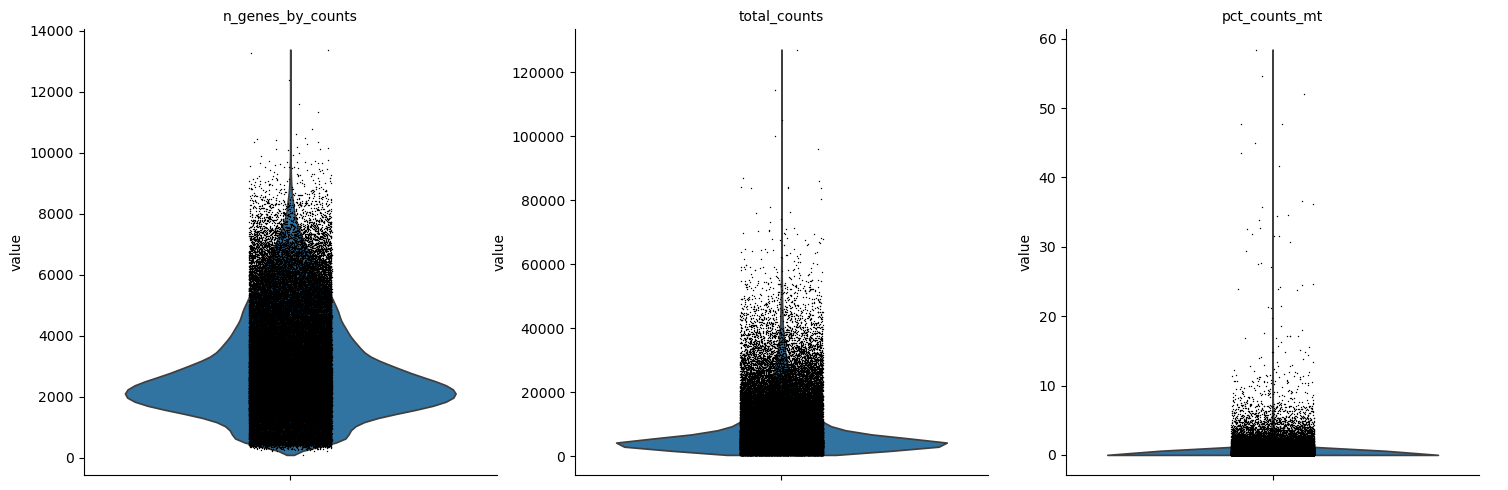

In [ ]:
# Violin plots
sc.pl.violin(
    adata,
    ["n_genes_by_counts", "total_counts", "pct_counts_mt"],
    multi_panel=True
)

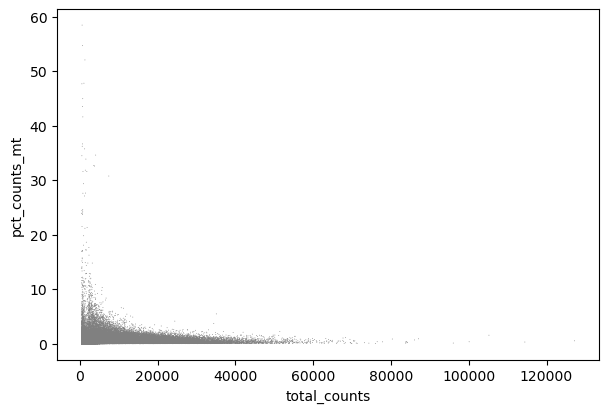

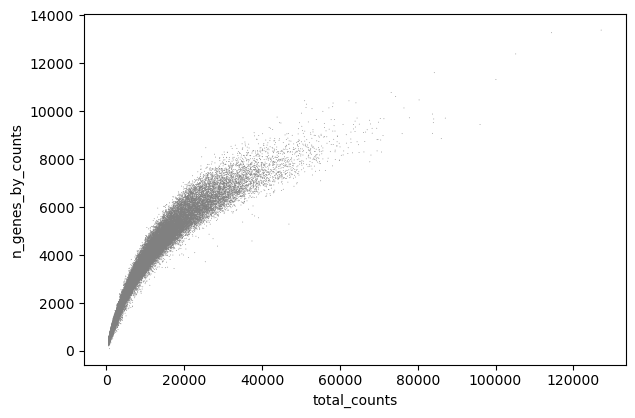

In [ ]:
# Scatter plots
sc.pl.scatter(adata, x="total_counts", y="pct_counts_mt")
sc.pl.scatter(adata, x="total_counts", y="n_genes_by_counts")

### Cell Filtering Based on Quality Control Metrics

Cells with too few genes, excessive counts,
or high mitochondrial content are removed.

Based on the inspection of the quality control **violin plots** and **scatter plots** (showing distributions of gene counts, total UMI counts, and mitochondrial gene percentages), empirical threshold values were selected to remove low‑quality and outlier cells. 

Specifically, cells with very low or excessively high numbers of detected genes, low total counts, or high mitochondrial gene content were excluded. These thresholds reflect the natural cutoffs observed in the QC visualizations and help retain biologically meaningful, high‑quality cells for downstream analysis.

In [8]:
adata = adata[
    (adata.obs.n_genes_by_counts > 200) &
    (adata.obs.n_genes_by_counts < 6000) &
    (adata.obs.total_counts > 1000) &
    (adata.obs.pct_counts_mt < 10),
    :
]

In [ ]:
# Dataset dimensions after filtering
adata.shape

(69339, 33538)

After filtering, 69339 cells and 33538 genes are left. 

## 3. Normalization and Highly Variable Genes, Dmensionality Reduction

Expression values are normalized, log‑transformed,
and the most informative genes are selected.

### Dimensionality Reduction

Then, Principal Component Analysis (PCA) is used for dimensionality reduction and UMAP
for visualization and clustering.

In [ ]:
# Normalize total counts
sc.pp.normalize_total(adata, target_sum=1e4)

# Log transformation
sc.pp.log1p(adata)

# Identify highly variable genes
sc.pp.highly_variable_genes(adata, n_top_genes=2000)


# Subset to HVGs
adata = adata[:, adata.var.highly_variable]

# Scale data
sc.pp.scale(adata, max_value=10)

# 4. PCA
sc.tl.pca(adata)


In [ ]:
# Save after PCA

adata.write("adata_after_pca.h5ad")

In [ ]:
# Reload
adata = sc.read_h5ad("adata_after_pca.h5ad")

In [ ]:

# Compute neighborhood graph
sc.pp.neighbors(adata)


# UMAP embedding
sc.tl.umap(adata)

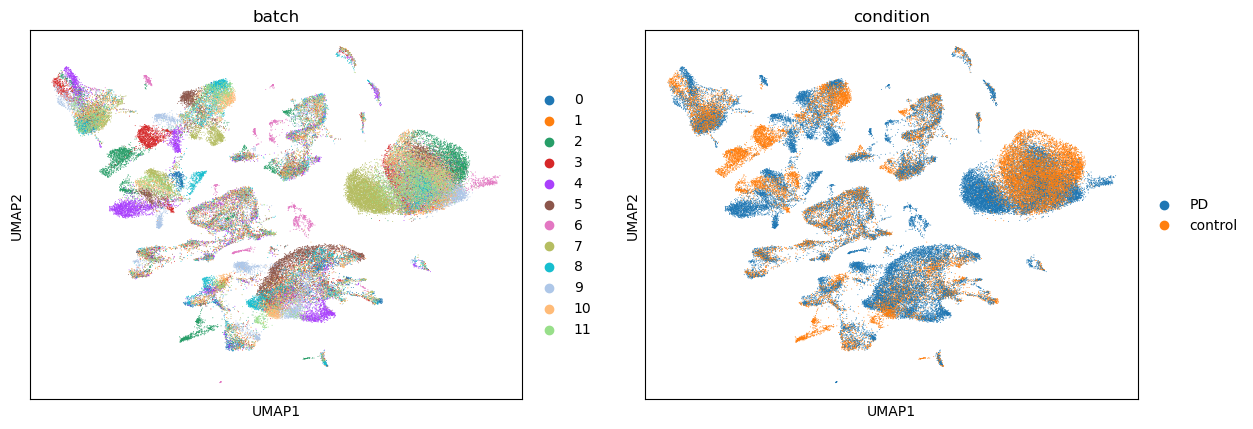

In [ ]:
# UMAP visualization
sc.pl.umap(adata, color=["batch", "condition"])

The UMAP embedding shows substantial overlap between Parkinson’s disease and control cells, indicating shared cellular populations, while the presence of PD‑enriched clusters suggests condition‑specific transcriptional states associated with Parkinson’s disease.

The batch UMAP shows good mixing of cells from different batches across clusters, suggesting that batch effects are minimal and do not strongly drive the observed transcriptional structure of the data.



## 4. Clustering and Marker Gene Identification

Leiden clustering is used to identify transcriptionally
distinct cell populations.
Then, marker genes are extracted for each cluster.

In [ ]:
# Preview dataset 
adata

AnnData object with n_obs × n_vars = 69339 × 2000
    obs: 'sample', 'condition', 'batch', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'leiden'
    var: 'gene_ids', 'feature_types', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'hvg', 'log1p', 'pca', 'neighbors', 'umap', 'batch_colors', 'condition_colors', 'leiden'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'

In [8]:
#leiden clustering
sc.tl.leiden(
    adata,
    flavor="igraph",
    n_iterations=2,
    directed=False
)

Marker genes per cluster  
Cluster‑specific marker genes were identified by comparing gene expression across Leiden clusters using the Wilcoxon rank‑sum test. This analysis highlights genes that are significantly enriched in each cluster, enabling biological interpretation and cell‑type annotation of the identified cell populations.

Marker genes by condition  
Differential gene expression analysis between Parkinson’s disease (PD) and control samples was performed using the Wilcoxon rank‑sum test. This approach identifies genes that are significantly up‑ or down‑regulated between conditions, providing insight into disease‑associated transcriptional changes.


In [ ]:
# Marker genes per cluster
sc.tl.rank_genes_groups(
    adata,
    groupby="leiden",
    method="wilcoxon",
    key_added="rank_leiden"
)

# Marker genes by condition
sc.tl.rank_genes_groups(
    adata,
    groupby="condition",
    method="wilcoxon",
    key_added="rank_condition"
)

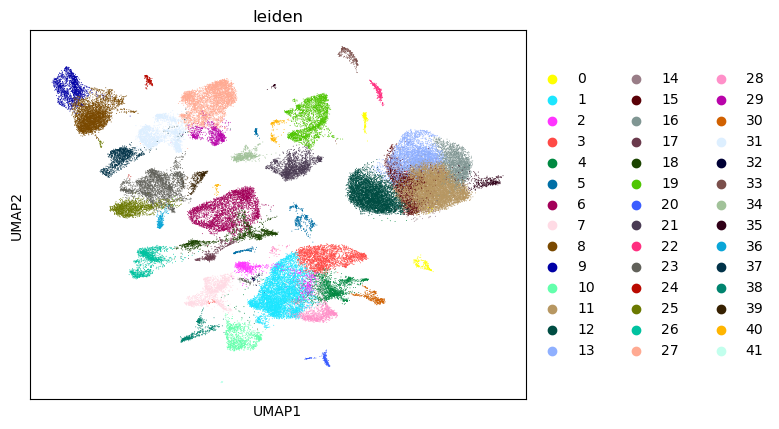

In [ ]:
# Plot clusters
sc.pl.umap(adata, color="leiden")

The Leiden UMAP shows that cells are partitioned into multiple well‑defined clusters based on transcriptional similarity, with clear separation between clusters and relatively compact internal structure. 

This indicates that the Leiden algorithm successfully identified distinct cellular populations or cell states present in the dataset, which form the basis for downstream marker gene analysis and biological interpretation.



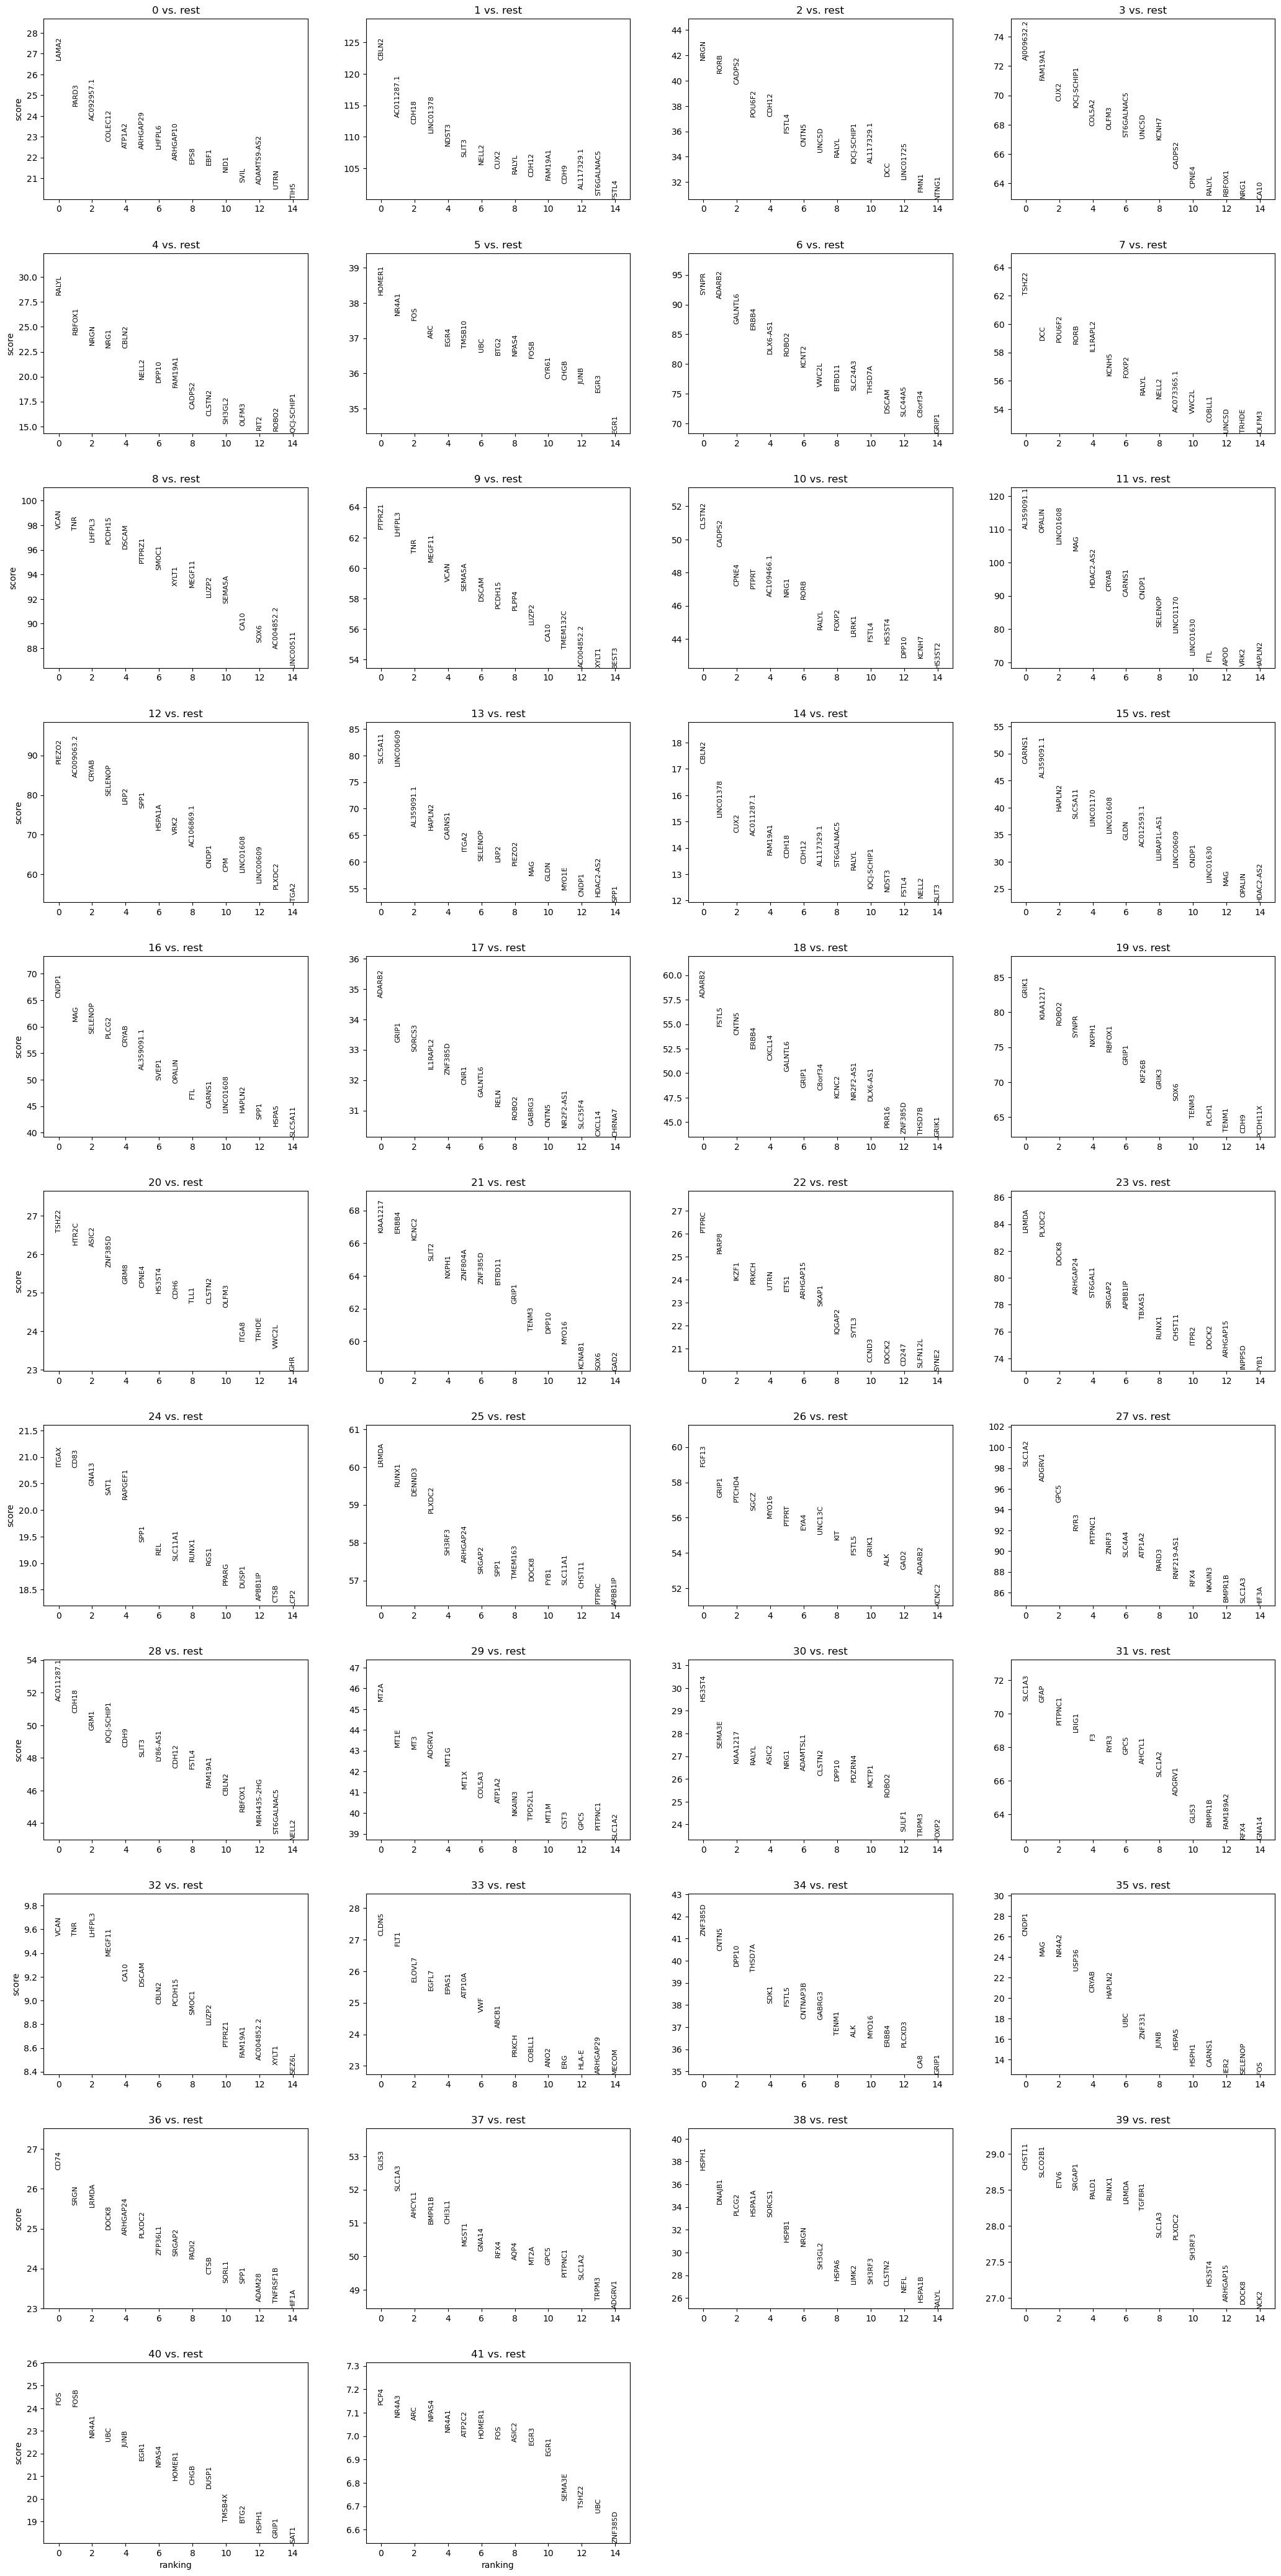

In [ ]:
#View top markers per cluster
sc.pl.rank_genes_groups(
    adata,
    n_genes=15,
    sharey=False,
    key="rank_leiden"
)

In [ ]:
# Save dataset after clustering and ranking genes
adata.write("adata_after_clustering_and_ranking_genes.h5ad")

## 5. Differential Expression Analysis
Differential expression analyses were performed to identify cluster‑specific marker genes and to compare gene expression between Parkinson’s disease and control samples.


### Export Marker Genes

Cluster‑specific marker genes were extracted into a tabular format using get.rank_genes_groups_df, enabling easy inspection and downstream analysis of the top differentially expressed genes identified for each Leiden cluster.

In [ ]:
# Extract cluster marker genes
cluster_gene_markers = sc.get.rank_genes_groups_df(
    adata,
    group=None,
    key="rank_leiden"
)

cluster_gene_markers.head()


,group,names,scores,logfoldchanges,pvals,pvals_adj
0,0,LAMA2,26.678816,NaN,8.291344e-157,1.658269e-153
1,0,PARD3,24.492771,NaN,1.763796e-132,1.763796e-129
2,0,AC092957.1,23.789040,NaN,4.336798e-125,2.891199e-122
3,0,COLEC12,22.781473,NaN,6.999833e-115,3.499916e-112
4,0,ATP1A2,22.453051,NaN,1.194820e-111,4.779282e-109


In [ ]:
#save cluster marker genes to CSV for downstream analysis
cluster_gene_markers.to_csv("DE_leiden_cluster_gene_markers_all_clusters.csv")

A curated list of well‑established brain cell‑type marker genes from the literature was cross‑referenced with the cluster‑specific marker genes to identify clusters expressing known markers, thereby facilitating biological annotation of the identified cell populations.

In [ ]:
# Known brain cell markers
marker_genes = ["GFAP", "MBP", "MOG", "P2RY12", "CX3CR1", "CD3D", "TRAC", "SNAP25", "RBFOX3"] #referenced from literature for brain cell types


In [ ]:
# Find known markers in cluster marker list
found_markers = cluster_gene_markers[cluster_gene_markers["names"].isin(marker_genes)]
found_markers

,group,names,scores,logfoldchanges,pvals,pvals_adj
900,0,CD3D,-0.015527,0.377749,0.987612,0.999625
1349,0,CX3CR1,-0.569652,7.136045,0.568913,0.992002
1634,0,P2RY12,-1.726320,NaN,0.084290,0.225073
1767,0,GFAP,-2.913994,NaN,0.003568,0.013047
2799,1,CD3D,-0.068079,0.418487,0.945723,0.999126
...,...,...,...,...,...,...
81917,40,GFAP,-3.964194,NaN,0.000074,0.000624
82297,41,P2RY12,0.809254,NaN,0.418369,0.999918
82470,41,CX3CR1,0.246424,NaN,0.805354,0.999918
82806,41,CD3D,-0.003399,0.375653,0.997288,0.999918


In [ ]:
# Save found markers to CSV
found_markers[["group", "names"]].to_csv('found_markers.csv')

Now, The top differentially expressed genes for each Leiden cluster were extracted and displayed to examine the most strongly enriched marker genes characterizing each cellular cluster.

In [ ]:
# Extract DE results
for cl in adata.obs["leiden"].cat.categories:
    print("\nCluster:", cl)
    print(
        sc.get.rank_genes_groups_df(
            adata,
            group=cl,
            key="rank_leiden"
        )[["names", "scores"]].head(10)
    )


Cluster: 0
        names     scores
0       LAMA2  26.678816
1       PARD3  24.492771
2  AC092957.1  23.789040
3     COLEC12  22.781473
4      ATP1A2  22.453051
5    ARHGAP29  22.413797
6      LHFPL6  22.410753
7    ARHGAP10  21.880739
8        EPS8  21.712078
9        EBF1  21.649672

Cluster: 1
        names      scores
0       CBLN2  122.155807
1  AC011287.1  113.069344
2       CDH18  112.030640
3   LINC01378  110.661804
4       NDST3  108.618874
5       SLIT3  106.782997
6       NELL2  105.638435
7        CUX2  104.950188
8       RALYL  104.183685
9       CDH12  103.653648

Cluster: 2
         names     scores
0         NRGN  41.610809
1         RORB  40.615948
2       CADPS2  39.724106
3       POU6F2  37.177979
4        CDH12  37.151630
5        FSTL4  35.916363
6        CNTN5  34.794289
7        UNC5D  34.399048
8        RALYL  34.005177
9  IQCJ-SCHIP1  33.507824

Cluster: 3
         names     scores
0   AJ009632.2  72.389313
1      FAM19A1  71.051315
2         CUX2  69.615288
3

Now, Genes differentially expressed between
Parkinson’s Disease and control samples
are identified and visualize

In [19]:
#Check condition labels
adata.obs["condition"].value_counts()

condition
PD         38312
control    31027
Name: count, dtype: int64

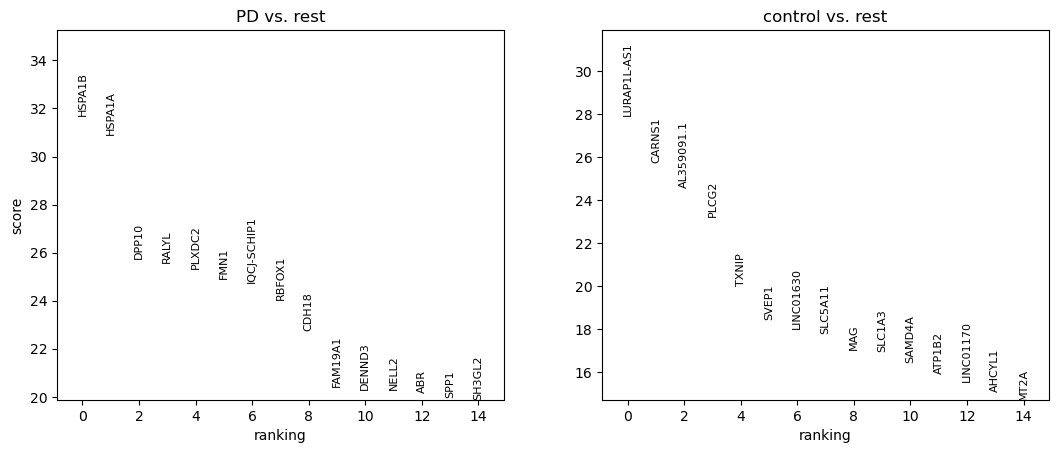

In [ ]:
#Rank genes by condition
sc.pl.rank_genes_groups(
    adata,
    n_genes=15,
    sharey=False,
    key="rank_condition"
)


- The chart displays the top differentially expressed genes ranked by their statistical scores for each condition.
- In the **PD vs. rest** panel, genes such as *HSPA1A*, *HSPA1B*, *DPP10*, and *RBFOX1* show the highest scores, indicating stronger association with Parkinson’s disease–related transcriptional changes. 
- In contrast, the **control vs. rest** panel highlights genes such as *LRP1-AS1*, *CARNS1*, and *PLCG2* as more characteristic of control samples. 
- The distinct gene rankings between the two panels demonstrate that PD and control conditions are driven by different transcriptional signatures, supporting the presence of condition‑specific molecular profiles.

In [ ]:
# Extract DE results
de_results_PD_and_control = sc.get.rank_genes_groups_df(adata, group=None, key="rank_condition")
de_results_PD_and_control.head()

,group,names,scores,logfoldchanges,pvals,pvals_adj
0,PD,HSPA1B,31.710018,NaN,1.130554e-220,2.261107e-217
1,PD,HSPA1A,30.883043,NaN,2.017845e-209,2.017845e-206
2,PD,DPP10,25.733936,NaN,4.877226e-146,1.950890e-143
3,PD,RALYL,25.587143,NaN,2.121067e-144,7.070223e-142
4,PD,PLXDC2,25.324213,NaN,1.728965e-141,4.939901e-139


In [ ]:
# Save the DE results to CSV for both conditions
de_results_PD_and_control.to_csv("DE_PD_vs_control_all_genes.csv")

In [ ]:
# Extract DE results for PD
de_results_PD = sc.get.rank_genes_groups_df(adata, group="PD", key="rank_condition")
de_results_PD.head()

,names,scores,logfoldchanges,pvals,pvals_adj
0,HSPA1B,31.710018,NaN,1.130554e-220,2.261107e-217
1,HSPA1A,30.883043,NaN,2.017845e-209,2.017845e-206
2,DPP10,25.733936,NaN,4.877226e-146,1.950890e-143
3,RALYL,25.587143,NaN,2.121067e-144,7.070223e-142
4,PLXDC2,25.324213,NaN,1.728965e-141,4.939901e-139


In [ ]:
# Save the DE results for PD to CSV for further analysis
de_results_PD.to_csv("DE_results_PD_all_genes.csv")

### Volcano Plot and Significant Gene Selection

A volcano plot was generated to visualize differential gene expression between Parkinson’s disease and control samples by plotting log2 fold changes against the negative log10‑transformed adjusted p‑values, enabling rapid identification of significantly regulated genes.

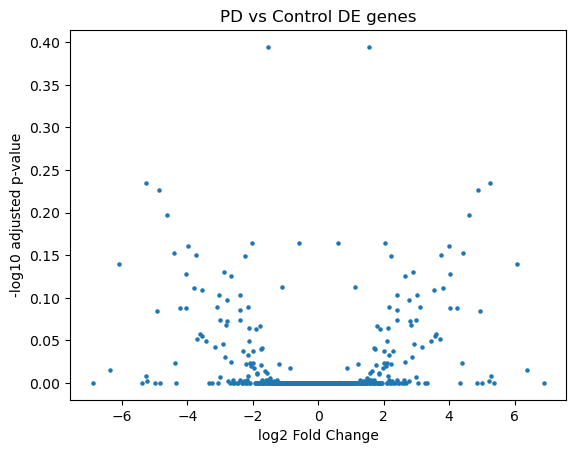

In [ ]:
#import required libraries
import numpy as np
import matplotlib.pyplot as plt

# Create a copy of the DataFrame for plotting
df = de_results_PD_and_control.copy()

#Volcano plot
plt.scatter(
    df["logfoldchanges"],
    -np.log10(df["pvals_adj"]),
    s=5
)

plt.xlabel("log2 Fold Change")
plt.ylabel("-log10 adjusted p-value")
plt.title("PD vs Control DE genes")
plt.show()

- In a volcano plot, higher values on the y‑axis (−log10 adjusted p‑value) indicate **greater statistical significance**.
- Genes farther to the left or right on the x‑axis show **larger decreases or increases in expression**, respectively.
- Genes appearing toward the **top corners of the plot** represent the most biologically relevant candidates, as they combine large fold changes with high statistical significance.

Although several genes display substantial fold changes in both directions, only a limited number achieve strong statistical significance, as indicated by the small number of genes with high −log10 adjusted p‑values. This suggests that Parkinson’s disease–associated transcriptional alterations are present

## 6. Gene Enrichment Analysis

Genes with an adjusted p‑value below 0.05 were selected as statistically significant differentially expressed genes in Parkinson’s disease, and the total number of such genes was quantified for downstream analysis.

In [ ]:
# Significant genes
sig = de_results_PD[de_results_PD["pvals_adj"] < 0.05]
gene_list = sig["names"].tolist()
len(gene_list)

748

There are 748 significant genes in Parkinson Disease samples.

In [ ]:
#Export gene list to text file for downstream analysis
sig["names"].to_csv("PD_significant_genes.txt", index=False, header=False)

Significant genes were uploaded to the g:Profiler web server (https://biit.cs.ut.ee/gprofiler/gost), the organism was set to *Homo sapiens*, and functional enrichment analysis was performed to identify over‑represented gene ontology terms and pathways.

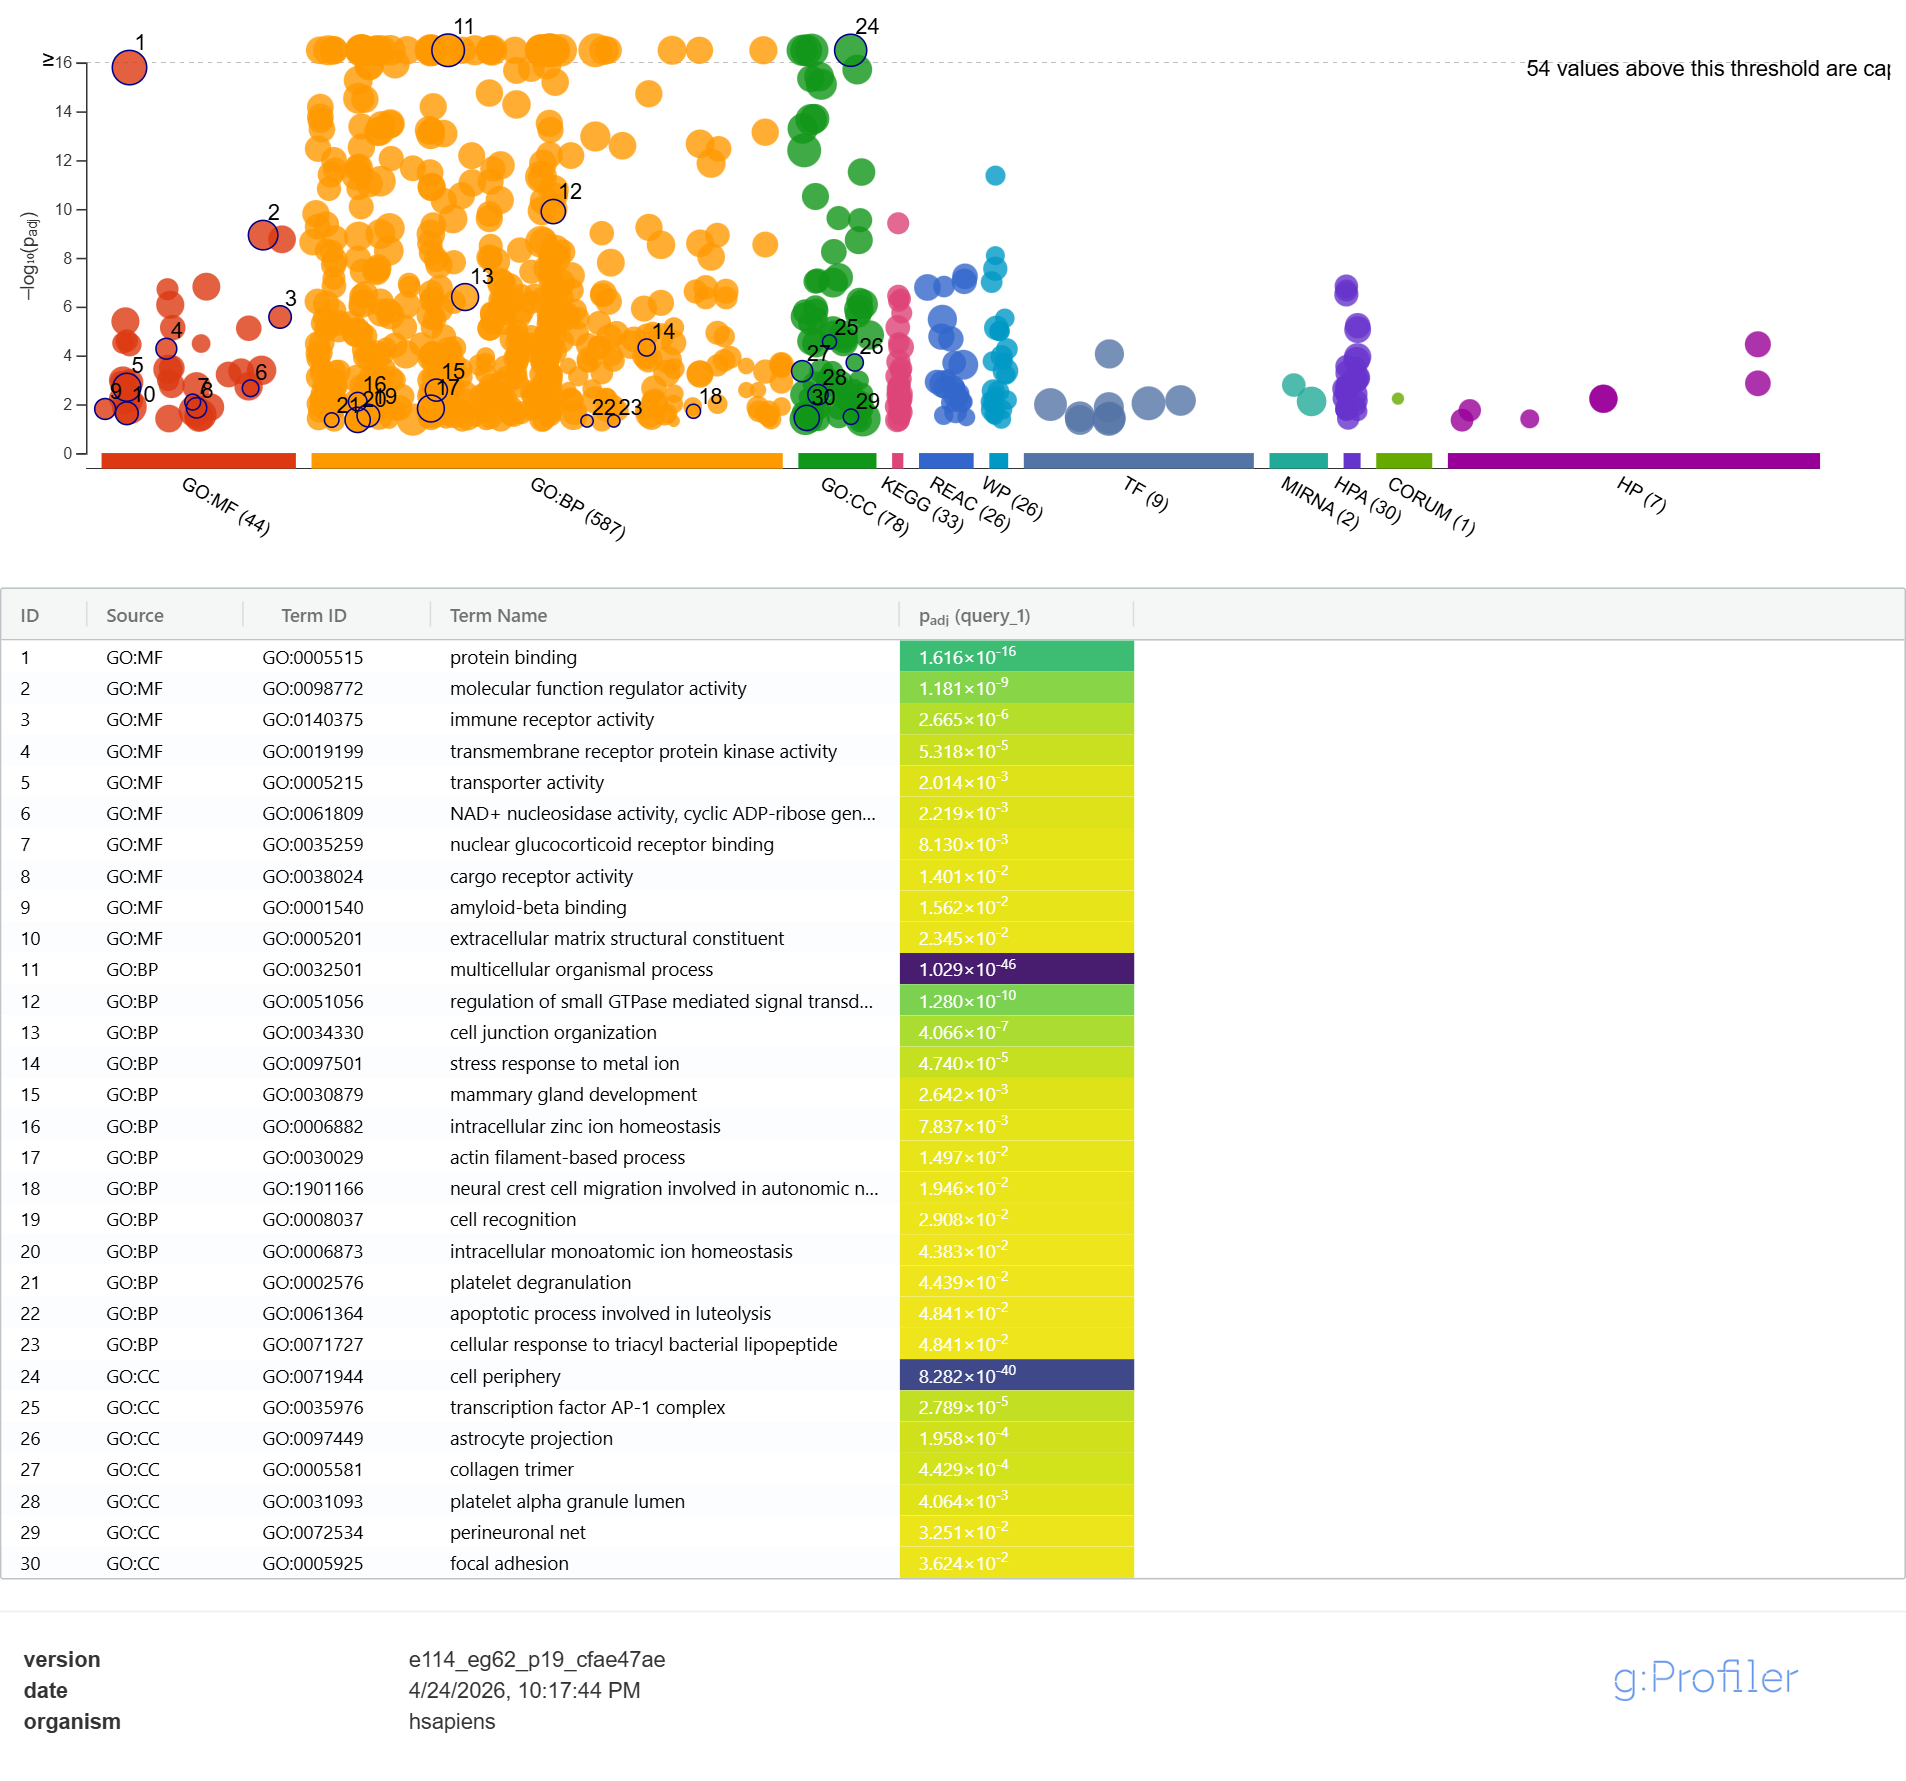

Gene ontology and pathway enrichment analysis of the significantly differentially expressed genes using g:Profiler revealed strong enrichment for multiple biological processes, molecular functions, and cellular components. 

Notably, highly significant terms were observed in GO Biological Process, including multicellular organismal processes, regulation of signal transduction, cytoskeletal organization, immune‑related responses, ion homeostasis, and stress‑response pathways, indicating widespread functional alterations associated with Parkinson’s disease. 

Enrichment in GO Molecular Function terms such as protein binding, immune receptor activity, and transmembrane receptor kinase activity suggests dysregulation of signaling and immune mechanisms. 

Additionally, GO Cellular Component terms, including astrocyte projections, cell periphery, perineuronal nets, and focal adhesion, point to changes in cell–cell interactions and glial involvement. 

Together, these results support the involvement of neuroinflammatory, signaling, and structural pathways in PD‑associated transcriptional changes and are consistent with the known multifactorial and cell‑type–specific pathology of Parkinson’s disease.


In [ ]:
# Summary statistics of p-values
de_results_PD["pvals"].describe()

count     2.000000e+03
mean      4.063438e-01
std       4.118111e-01
min      1.130554e-220
25%       3.786179e-05
50%       2.447278e-01
75%       8.837027e-01
max       9.997128e-01
Name: pvals, dtype: float64

The summary statistics of raw p‑values show that while most genes are not significantly differentially expressed (median p‑value ≈ 0.24)

A subset of genes exhibits extremely low p‑values, indicating strong evidence of differential expression between PD and control samples. 

The wide spread of p‑values, ranging from near zero to nearly one, reflects substantial heterogeneity in gene‑level significance, which is expected in genome‑wide differential expression analyses.



## 7. Machine Learning Classification

A Random Forest classifier is trained using
top differentially expressed genes to predict
PD vs control samples.

In [ ]:
#import required libraries for machine learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, roc_curve


In [ ]:

# Select top 50 genes by adjusted p-value and sort by adjusted p-value
top50 = (
    de_results_PD_and_control
    .copy()
    .sort_values("pvals_adj")
    .head(50)["names"]
    .tolist()
)

In [ ]:
# extract expression matrix for selected genes
X = adata[:, top50].X

# convert to dense if sparse
if not isinstance(X, np.ndarray):
    X = X.toarray()

# labels
y = adata.obs["condition"].values

In [ ]:
# Encode labels
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_encoded = le.fit_transform(y)  # PD=1, Control=0 (or vice versa)

In [ ]:
#Train / test    split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

In [ ]:
#Train the Random Forest model
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [49]:
# Make predictions on test set
y_pred = rf.predict(X_test)
y_prob = rf.predict_proba(X_test)[:, 1]

In [ ]:
#Evaluate with multiple metrics (accuracy, F1 score, ROC-AUC)
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc_score = roc_auc_score(y_test, y_prob)

print(f"Test Accuracy: {acc:.3f}")
print(f"Test F1 Score: {f1:.3f}")
print(f"Test ROC-AUC: {auc_score:.3f}")

Test Accuracy: 0.749
Test F1 Score: 0.708
Test ROC-AUC: 0.831


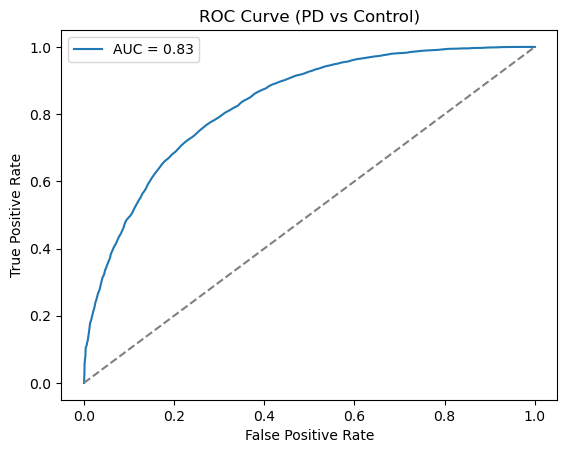

In [51]:
#Plot ROC curve
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.2f}")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (PD vs Control)")
plt.legend()
plt.show()


- The Random Forest model achieved a test accuracy of 74.9%, indicating that the majority of cells were correctly classified as Parkinson’s disease or control.  
- An F1 score of 0.708 suggests a balanced performance between precision and recall, reflecting reasonable robustness in handling class imbalance.  
- The ROC‑AUC score of 0.831 indicates strong discriminative ability, demonstrating that the model effectively distinguishes between PD and control samples - based on gene expression patterns.
- Overall, the model demonstrates a strong predictive signal in gene expression data for distinguishing Parkinson’s disease from control samples, 


### Feature Importance Analysis

Top genes contributing to disease prediction
are ranked based on Random Forest importance scores.

In [54]:
#feature importance
rf.fit(X, y_encoded)
importances = rf.feature_importances_

importance_df = (
    pd.DataFrame({
        "gene": top50,
        "importance": importances
    })
    .sort_values("importance", ascending=False)
)

importance_df.head(10)

,gene,importance
22,PLCG2,0.032974
21,RBFOX1,0.032444
23,PLCG2,0.032238
20,RBFOX1,0.030758
13,PLXDC2,0.030121
3,HSPA1A,0.030106
9,DPP10,0.030074
7,DPP10,0.029856
12,PLXDC2,0.029796
2,HSPA1A,0.029358


- The feature importance analysis indicates that genes such as PLCG2, RBFOX1, PLXDC2, HSPA1A, and DPP10 contribute most strongly to the Random Forest model’s predictions. 

- The similar importance values suggest that disease classification is driven by the combined contribution of multiple genes, rather than reliance on a single dominant marker, reflecting the polygenic and heterogeneous nature of Parkinson’s disease–associated transcriptional changes.



- The overlap of RBFOX1, PLXDC2, HSPA1A, and DPP10 among the top Random Forest features and the highest‑ranking genes in the PD vs. rest analysis indicates that these genes are both statistically differentially expressed and highly informative for classification, suggesting they represent robust transcriptional signatures associated with Parkinson’s disease.

- these genes are robust candidate biomarkers for Parkinson’s disease, although further validation in independent datasets would be required to confirm their biomarker potential.



## Conclusion

In this study, single‑cell RNA‑sequencing data from the GSE202210 dataset were analyzed to characterize transcriptional alterations associated with Parkinson’s disease. Through quality control, normalization, dimensionality reduction, and Leiden clustering, distinct cellular populations were identified, revealing both shared and PD‑enriched transcriptional states. Differential expression and gene enrichment analyses highlighted pathways related to immune signaling, stress responses, ion homeostasis, and cellular structural components, consistent with the complex and multifactorial nature of PD pathology. Furthermore, machine‑learning modeling using a Random Forest classifier demonstrated strong discriminatory power between PD and control samples, with feature importance analysis identifying key genes contributing to disease classification. Overall, this integrated single‑cell, statistical, and machine‑learning approach provides insights into PD‑associated molecular signatures and identifies candidate genes and biological processes for further investigation and validation.

